# STEP 1 : INSTALL LIBRARIES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 2 : LOAD DATASET
sep = seperator
"columns are seperated using semicolons"

In [44]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/student/student-mat.csv',sep = ';')
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# **DATA CLEANING SECTION**

# STEP 3 : CHECK MISSING VALUES

In [16]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


# STEP 4 : REMOVE DUPLICATE VALUES

In [18]:
df = df.drop_duplicates()
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# STEP 5 : CHECK DATASET SHAPE

In [19]:
df.shape

(395, 33)

# STEP 6 : CHECK DATA TYPES

In [23]:
df.dtypes

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


# **DATA ANALYSIS SECTION**

# STEP 7 : FIND AVERAGE FINAL GRADE

In [37]:
final_avg_grade = df["G3"].mean()
print(f"The Average Final Grade : {final_avg_grade:.2f} ")

The Average Final Grade : 10.42 


# STEP 8 : STUDENTS SCORING ABOVE 15

In [30]:
scores_above = df[df["G3"] > 15]
print(scores_above)

print("Total Students : ",len(scores_above))

    school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
8       GP   M   15       U     LE3       A     3     2  services     other   
14      GP   M   15       U     GT3       A     2     2     other     other   
22      GP   M   16       U     LE3       T     4     2   teacher     other   
31      GP   M   15       U     GT3       T     4     4  services  services   
32      GP   M   15       R     GT3       T     4     3   teacher   at_home   
36      GP   M   15       U     LE3       T     4     3   teacher  services   
42      GP   M   15       U     GT3       T     4     4  services   teacher   
47      GP   M   16       U     GT3       T     4     3    health  services   
59      GP   F   16       U     GT3       T     4     2  services     other   
69      GP   F   15       R     LE3       T     3     1     other     other   
91      GP   F   15       U     GT3       T     4     3  services     other   
101     GP   M   16       U     GT3       T     4   

# STEP 9 : Correlation Between Study Time and Grades

Correlation means:

Does one thing change when another changes?

Example:

More study time → Higher grades?

In [34]:
correlation = df["studytime"].corr(df["G3"])
print(f"Correlation between study time and grades: {correlation:.2f}")

Correlation between study time and grades: 0.10


# STEP 10 : GENDER WISE AVERAGE

In [38]:
gender_avg = df.groupby("sex")["G3"].mean()
print(gender_avg)

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


# **VISUALIZATIONS**

# STEP 11 : HISTOGRAM OF GRADES

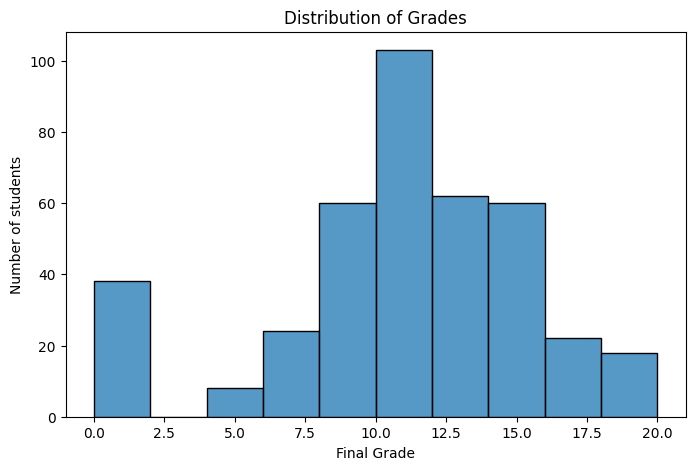

In [40]:
plt.figure(figsize = (8,5))

sns.histplot(df["G3"],bins = 10)
plt.title("Distribution of Grades")
plt.xlabel("Final Grade")
plt.ylabel("Number of students")

plt.show()

# STEP 12 : SCATTER PLOT : STUDY TIME VS GRADES

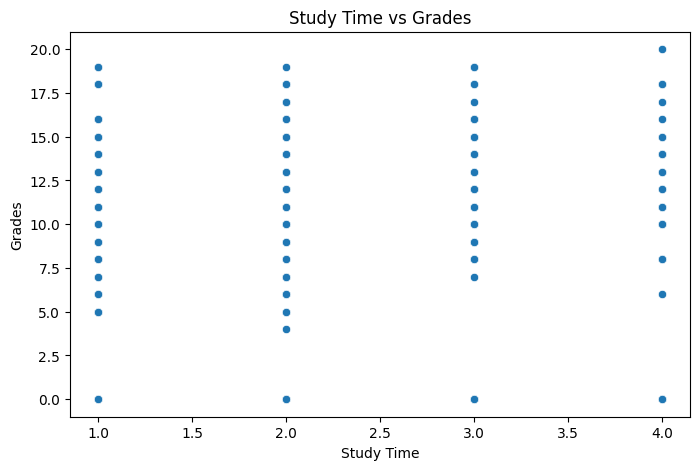

In [41]:
plt.figure(figsize = (8,5))

sns.scatterplot(x = df["studytime"],y = df["G3"])
plt.title("Study Time vs Grades")
plt.xlabel("Study Time")
plt.ylabel("Grades")

plt.show()

# STEP 13 : BAR CHART : MALES VS FEMALES AVERAGE SCORES

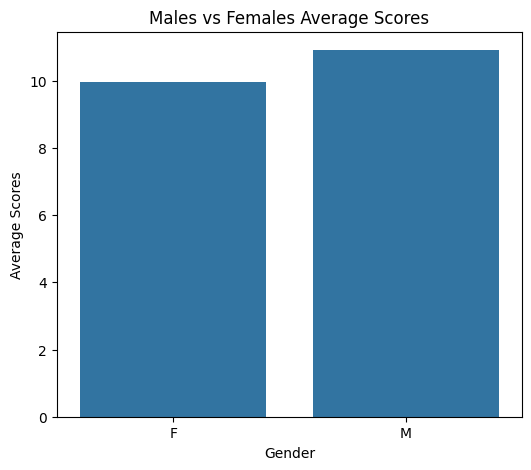

In [42]:
plt.figure(figsize = (6,5))

sns.barplot(x=gender_avg.index,y = gender_avg.values)
plt.title("Males vs Females Average Scores")
plt.xlabel("Gender")
plt.ylabel("Average Scores")

plt.show()